# Face Mask Detection: YOLO26n Training (Colab)

Before running: **Runtime > Change runtime type > T4 GPU**.

Before running: zip the *contents* of your FaceMaskDetection folder
(select `train`, `valid`, `test`, `data.yaml`, then right-click > Send to > Compressed folder),
name it `FaceMaskDetection.zip`, and upload it to the top level of your Google Drive (My Drive).

## Step 1: Check the GPU and install Ultralytics

In [ ]:
!nvidia-smi
!pip install -q -U ultralytics

Thu Oct  1 08:01:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Mount Google Drive and unzip the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/FaceMaskDetection.zip" -d /content/dataset

Mounted at /content/drive


## Step 3: Locate the dataset and write a Colab-safe data.yaml

Roboflow's relative paths (`../train/images`) break easily, so we write a fresh yaml with an absolute path.

In [ ]:
import glob, os

yaml_files = glob.glob('/content/dataset/**/data.yaml', recursive=True)
assert yaml_files, "data.yaml not found - check how the zip was created"
DATASET_DIR = os.path.dirname(yaml_files[0])
print("Dataset folder:", DATASET_DIR)

yaml_text = f"""path: {DATASET_DIR}
train: train/images
val: valid/images
test: test/images

nc: 3
names: ['Mask', 'Mask Incorrect', 'No Mask']
"""

with open('/content/data_colab.yaml', 'w') as f:
    f.write(yaml_text)

print(yaml_text)

Dataset folder: /content/dataset
path: /content/dataset
train: train/images
val: valid/images
test: test/images

nc: 3
names: ['Mask', 'Mask Incorrect', 'No Mask']



## Step 4: Train the baseline model

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo26n.pt')

model.train(
    data='/content/data_colab.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='/content/runs',
    name='baseline',
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_colab.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f4a8a0a1c50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## Step 5: Evaluate the best weights on the held-out TEST split

Watch the per-class rows: `Mask Incorrect` (about 4.7% of the data) and recall on `No Mask`.

In [ ]:
best = YOLO('/content/runs/baseline/weights/best.pt')
metrics = best.val(data='/content/data_colab.yaml', split='test')

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 994.2±701.0 MB/s, size: 62.9 KB)
val: Scanning /content/dataset/test/labels... 248 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 248/248 1.7Kit/s 0.1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.9it/s 5.4s
                   all        248        896       0.55      0.652      0.639      0.339
                  Mask        216        728      0.566      0.768      0.725      0.388
        Mask Incorrect         32         36      0.586      0.589      0.618      0.355
               No Mask         67        132      0.499      0.598      0.575      0.275
Speed: 2.3ms preprocess, 9.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Re

## Step 6: Save results

Copying to Drive first protects the results if the Colab session disconnects.

In [ ]:
!cp -r /content/runs/baseline "/content/drive/MyDrive/face_mask_baseline_results"
print("Saved to Google Drive: face_mask_baseline_results")

from google.colab import files
files.download('/content/runs/baseline/weights/best.pt')

Saved to Google Drive: face_mask_baseline_results


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

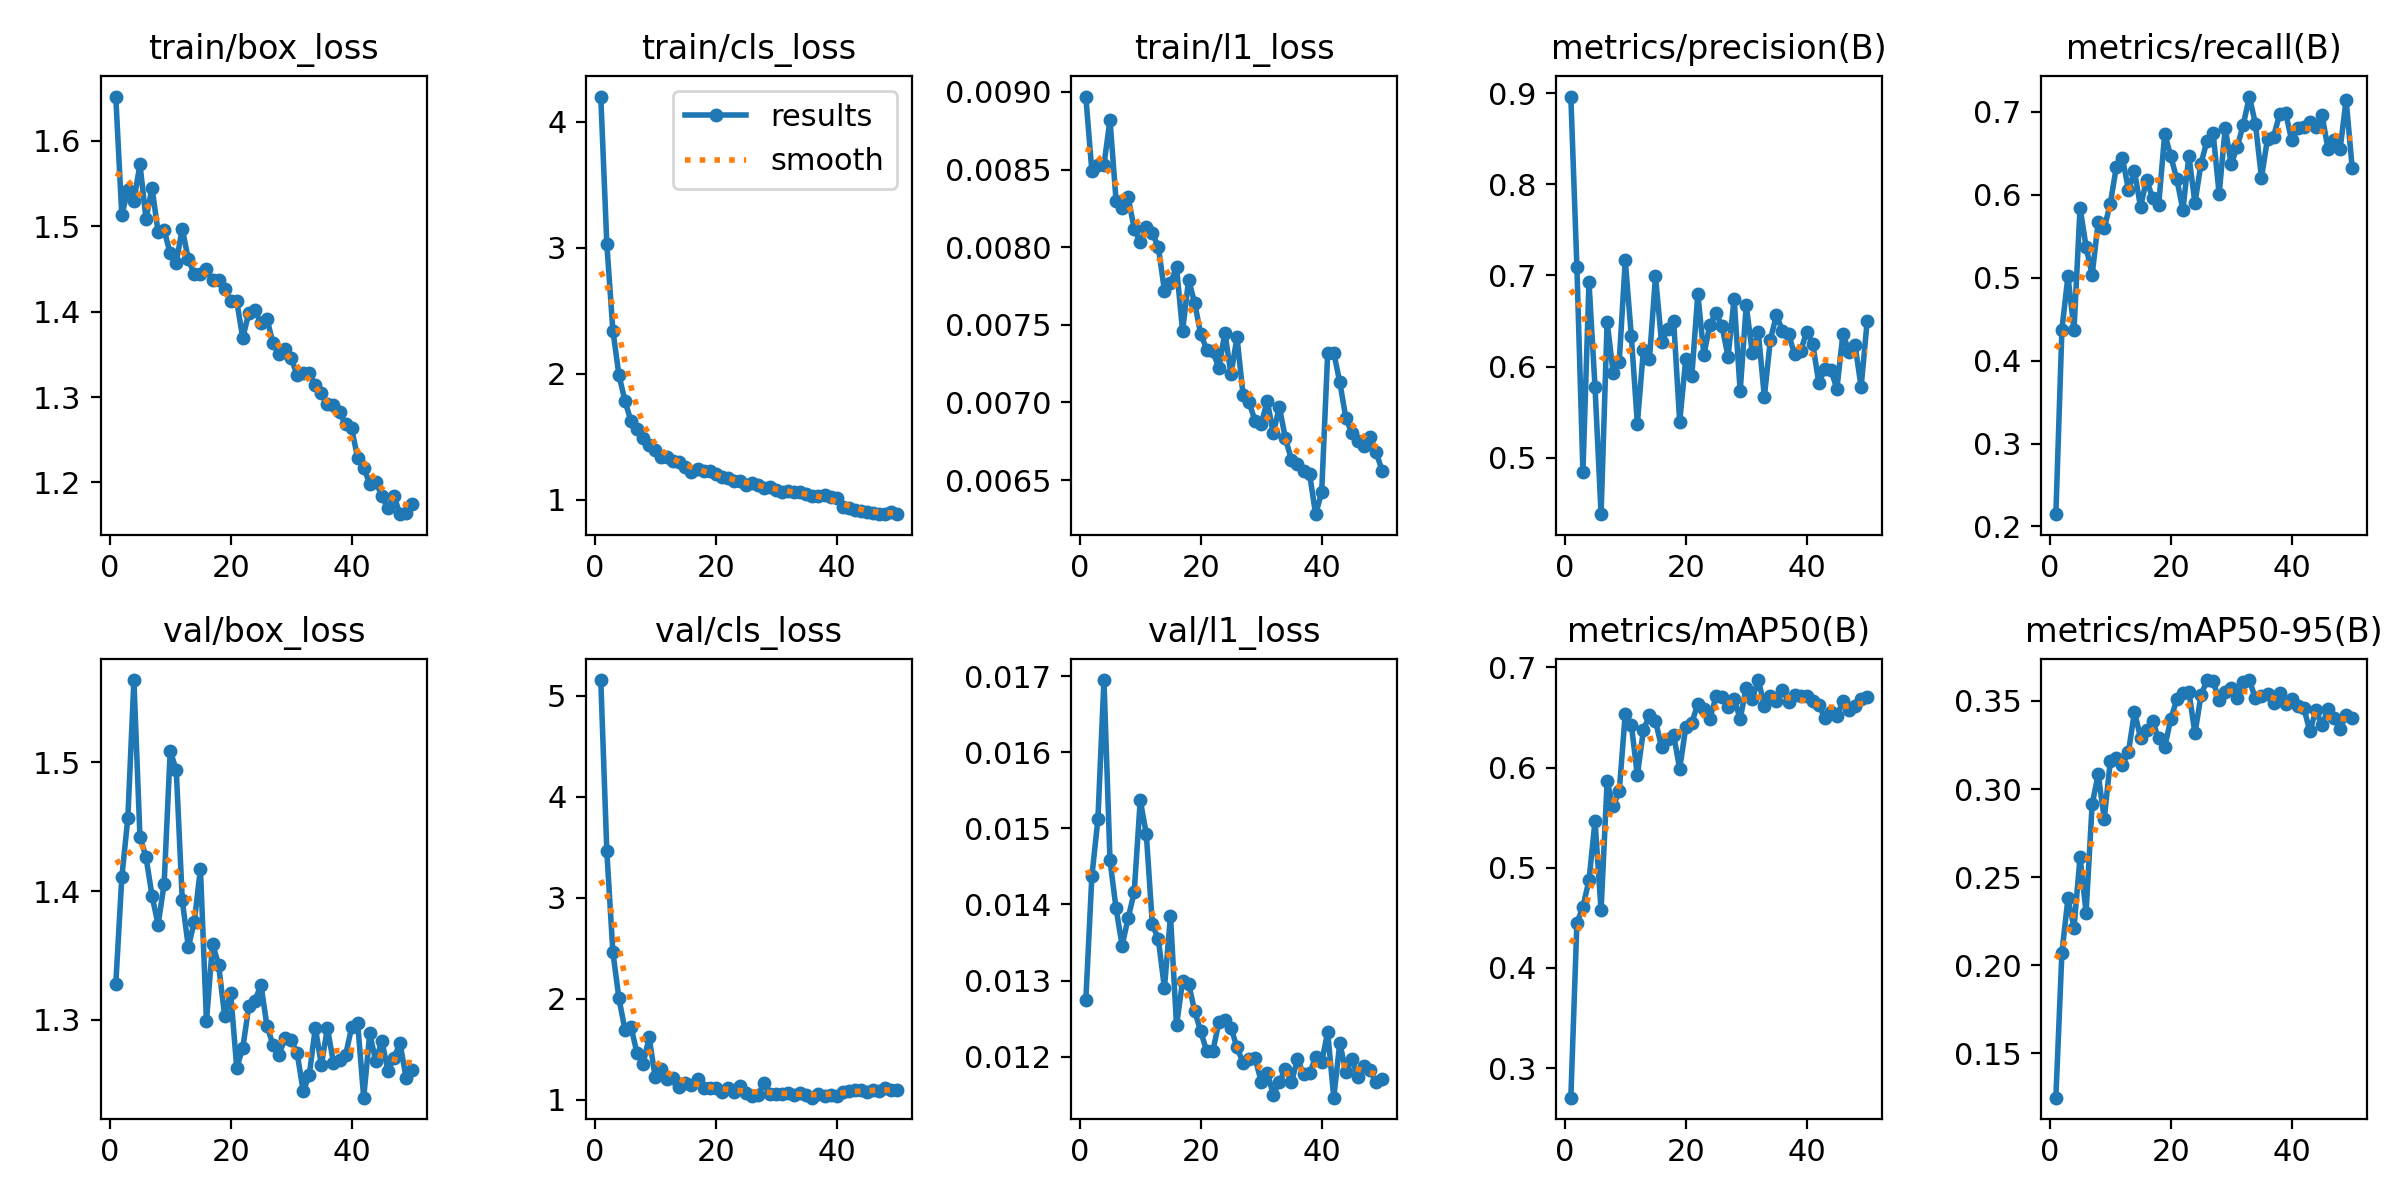

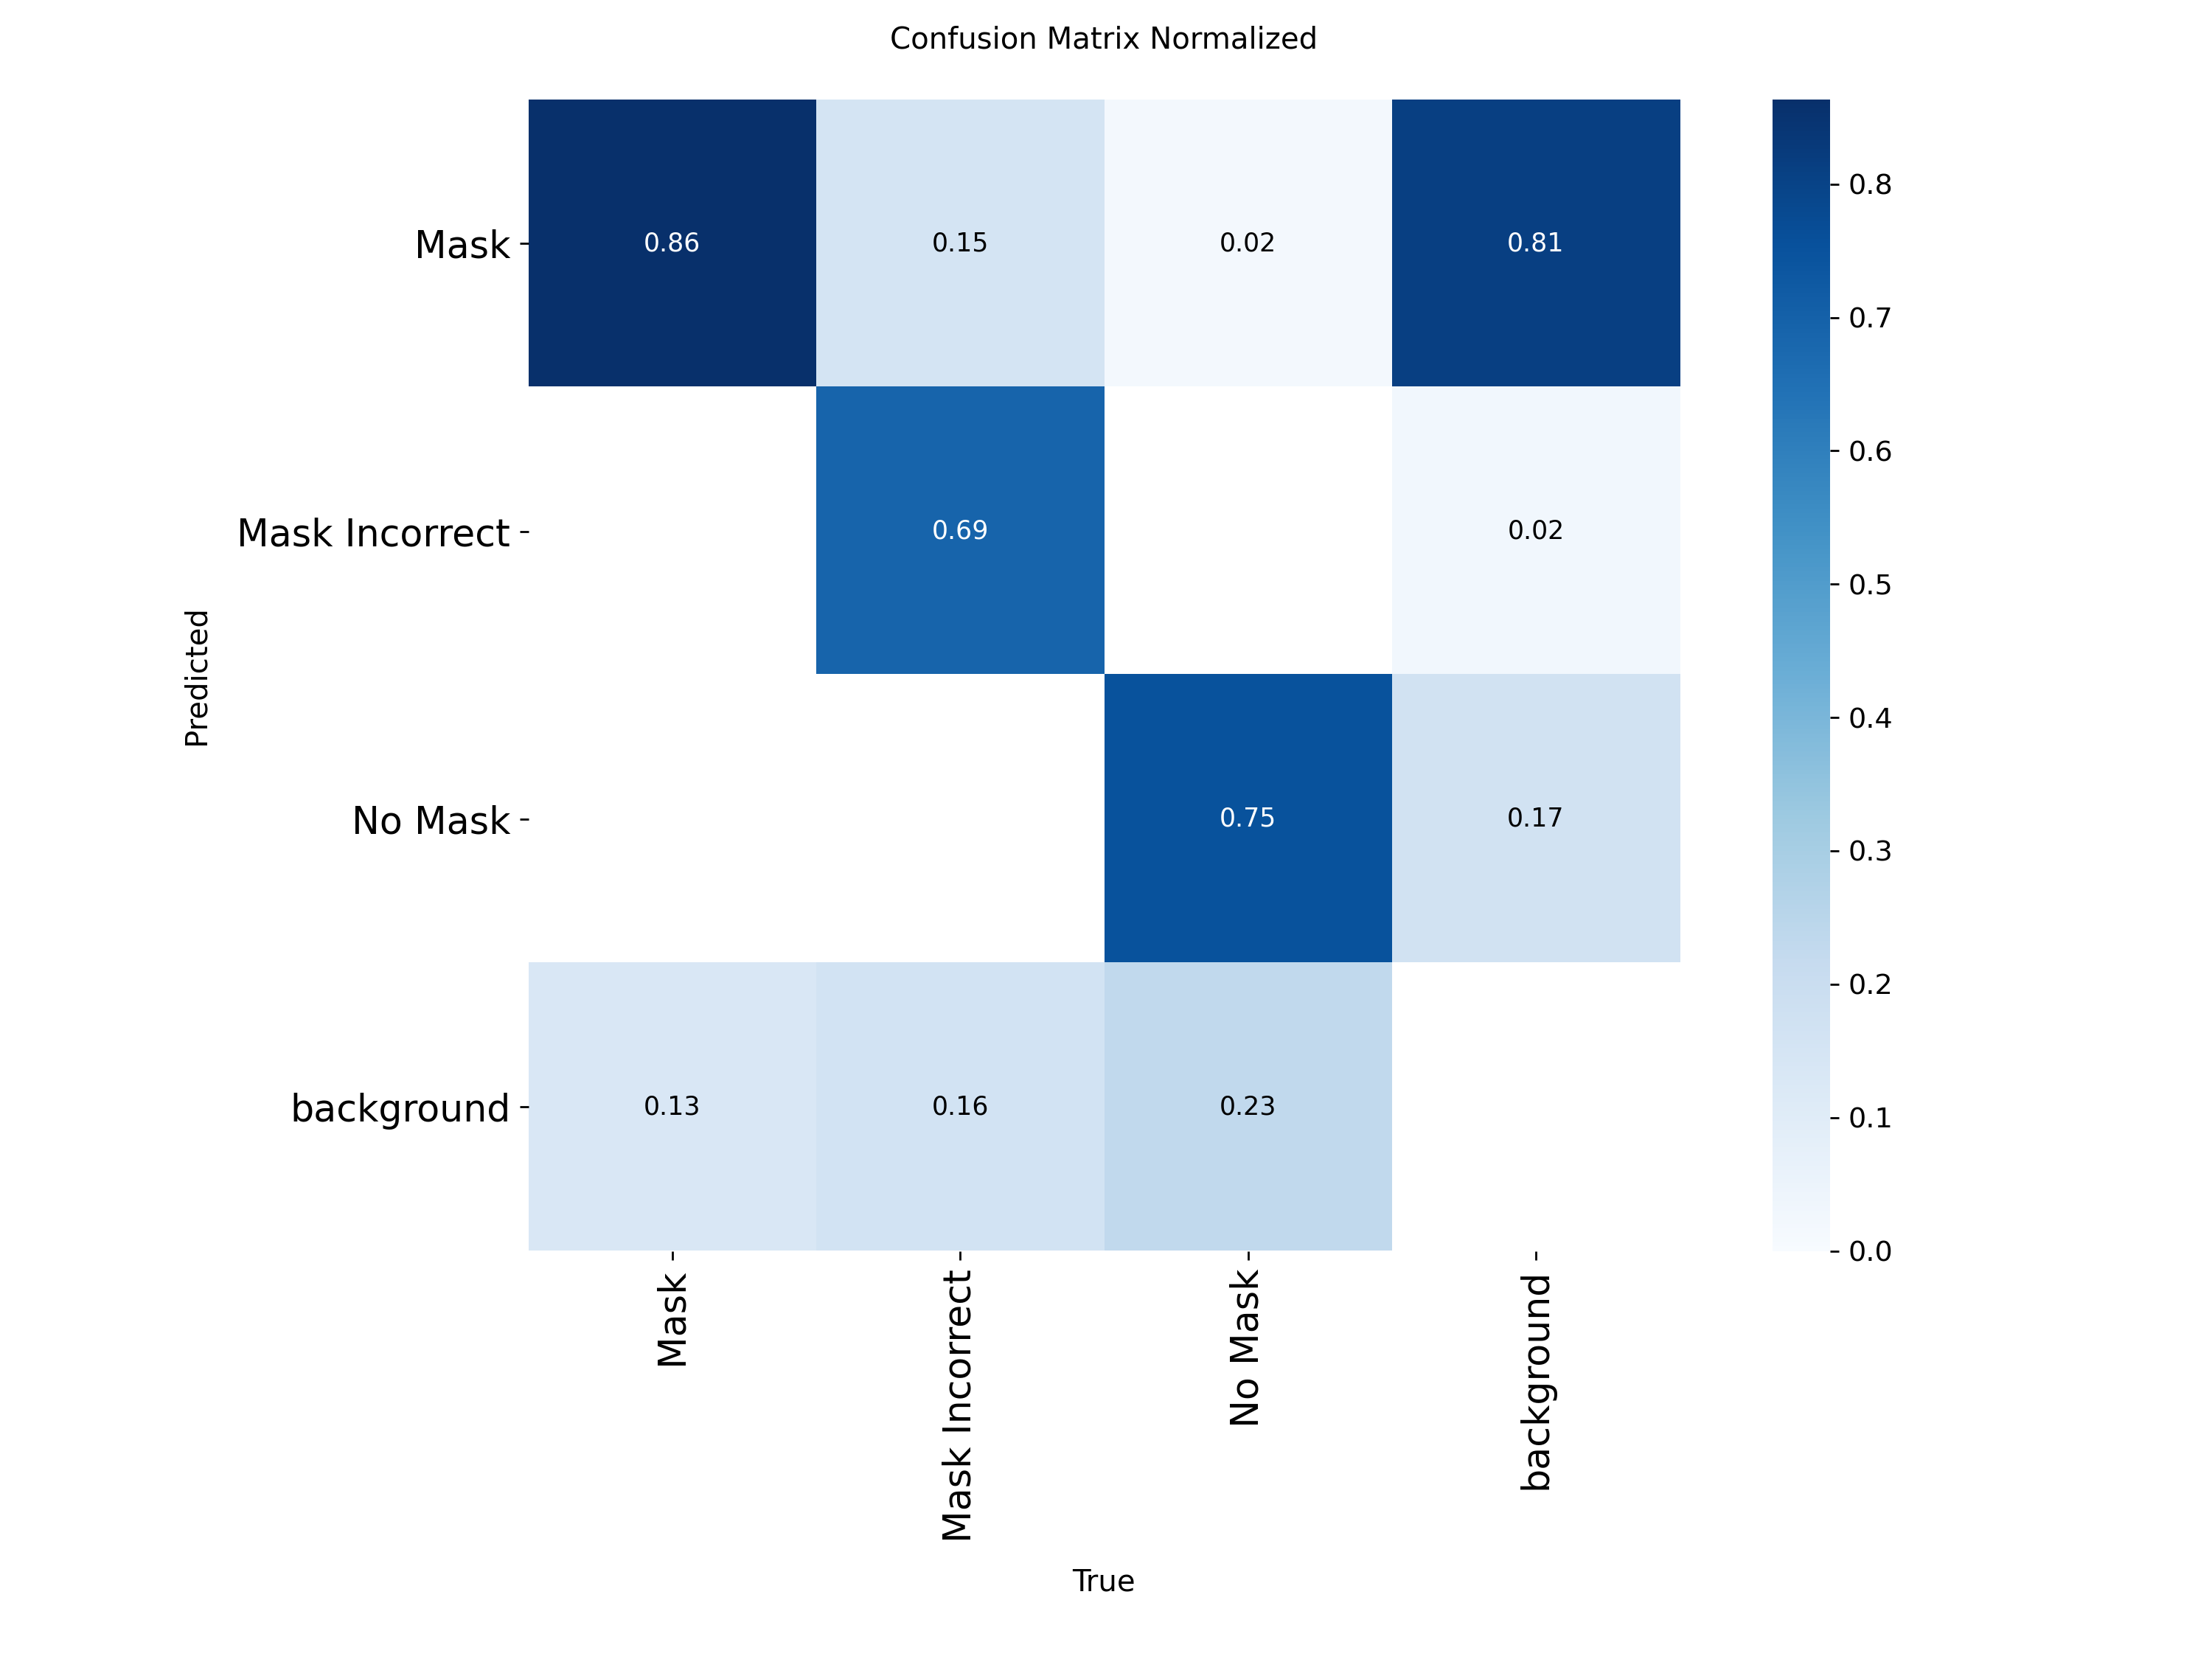

46,1730.65,1.16989,0.89318,0.00675,0.63593,0.65582,0.66628,0.34519,1.26035,1.09713,0.01173,0.000155761,0.000155761,0.000155761
47,1763.31,1.18404,0.89254,0.00672,0.6162,0.66563,0.65775,0.3404,1.2701,1.08582,0.01187,0.000127467,0.000127467,0.000127467
48,1796.45,1.1628,0.8873,0.00678,0.62349,0.65522,0.66132,0.33392,1.28209,1.11605,0.01182,9.91726e-05,9.91726e-05,9.91726e-05
49,1829.32,1.16389,0.90709,0.00668,0.57737,0.71458,0.66818,0.34203,1.255,1.09723,0.01166,7.08784e-05,7.08784e-05,7.08784e-05
50,1861.98,1.17445,0.88831,0.00656,0.64972,0.63239,0.67001,0.34001,1.26121,1.09687,0.01171,4.25842e-05,4.25842e-05,4.25842e-05


In [ ]:
from IPython.display import Image, display

display(Image('/content/runs/baseline/results.png'))
display(Image('/content/runs/baseline/confusion_matrix_normalized.png'))
!tail -n 5 /content/runs/baseline/results.csv